#### Importing Libraries

In [75]:
import numpy as np
import pandas as pd
import scipy
import random
from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt
from math import pi
from scipy.interpolate import NearestNDInterpolator

%matplotlib inline

#floris simulation modules
from floris.tools.wind_rose import WindRose
from floris.tools import FlorisInterface
import floris.tools.visualization as wakeviz
from floris.turbine_library import TurbineInterface, TurbineLibrary
from floris.tools.visualization import (
    calculate_horizontal_plane_with_turbines,
    visualize_cut_plane,
)

## Optimized Layouts

### WInd Rose

In [76]:
df_wind_montly = pd.read_csv('./2020_Daily_Avgs.csv')
df_wind_montly.head()

list_wd_bins = [0., 5., 10., 15., 20., 25., 30., 35., 40., 45., 50., 55., 60., 65., 70., 75., 80., 85., 90., 95., 100., 105., 110., 115., 120., 125., 130., 135., 140., 145., 150., 155., 160., 165., 170., 175., 180., 185., 190., 195., 200., 205., 210., 215., 220., 225., 230., 235., 240., 245., 250., 255., 260., 265., 270., 275., 280., 285., 290., 295., 300., 305., 310., 315., 320., 325., 330., 335., 340., 345., 350., 355.]

list_ws_bins = [0., 1., 2., 3., 4., 5., 6., 7., 8., 9., 10., 11., 12., 13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25., 26.]

windr = WindRose()

df_wind_calc = windr.make_wind_rose_from_user_data(wd_raw=df_wind_montly['average_wind_dir_deg'], ws_raw=df_wind_montly['Factorized_Mean'], wd=np.array(list_wd_bins), ws=np.array(list_ws_bins))


wd_array = np.array(df_wind_calc["wd"].unique(), dtype=float)
ws_array = np.array(df_wind_calc["ws"].unique(), dtype=float)


wd_grid, ws_grid = np.meshgrid(wd_array, ws_array, indexing="ij")
freq_interp = NearestNDInterpolator(df_wind_calc[["wd", "ws"]], df_wind_calc["freq_val"])
freq = freq_interp(wd_grid, ws_grid)

# Normalize the frequency array to sum to exactly 1.0
freq = freq / np.sum(freq)

Correcting negative Overhang:-2.5


### Floris Interface

In [77]:
fi_nrel = FlorisInterface('./gch.yaml')
fi_vestas = FlorisInterface('./gch_vestas.yaml')

In [78]:
def aep_powers(fi, df):
    power_list = []
    fi.reinitialize(
        layout_x=df["Layout_x"],
        layout_y=df['Layout_y'],
        wind_directions=wd_array,
        wind_speeds=ws_array,
    )

    aep = fi.get_farm_AEP(
        freq=freq,
        cut_in_wind_speed=4.0,  # Wakes are not evaluated below this wind speed
        cut_out_wind_speed=25.0,  # Wakes are not evaluated above this wind speed
    )
    power_list.append(round((aep / 1.0e9), 3))

    aep_no_wake = fi.get_farm_AEP(freq, no_wake=True)
    power_list.append(round((aep_no_wake / 1.0e9), 3))

    percentage_power_loss = (aep_no_wake - aep) / aep_no_wake * 100
    power_list.append(round(percentage_power_loss, 3))


    return power_list

#### Defining Populations

#### Defining Parameters

In [79]:
min_distance = 126
tournament_size = 3
target_coverage_area = 800000
turbine_diameter = 126
mutation_rate = 0.3

### The GA Implmentation

/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)


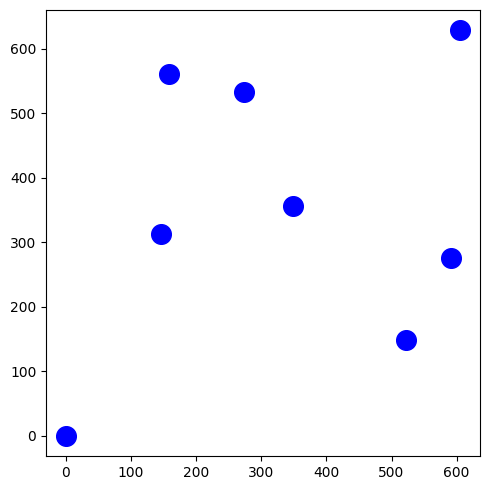

     Layout_x    Layout_y
0    0.000000    0.000000
1  158.414073  560.426234
2  591.997439  275.669379
3  522.744562  149.360001
4  272.899932  534.002328
5  146.266880  313.209954
6  348.980075  356.409322
7  605.510588  628.900504
Enclosed area:  250394.00927553477


In [80]:
def initialize_populations():
    populations = []
    for num_turbines in np.repeat(range(3, 9), 4):  # Generate 24 initial populations
        layout = pd.DataFrame(columns=['Layout_x', 'Layout_y'])
        layout.loc[0] = [0, 0]  # Set the first turbine at the origin
        for _ in range(1, num_turbines):
            while True:
                new_turbine = pd.DataFrame(np.random.uniform(126, 630, size=(1, 2)), columns=['Layout_x', 'Layout_y'])
                if all(np.linalg.norm(layout[['Layout_x', 'Layout_y']].values - new_turbine.values, axis=1) >= 126):
                    temp_df = pd.concat([layout, new_turbine], ignore_index=True)
                    layout = temp_df.copy()  # Assign the concatenated DataFrame back to layout
                    break
        populations.append(layout)
    return populations


def calculate_fitness(layout):
    num_turbines = len(layout)
    distances = scipy.spatial.distance.pdist(layout[['Layout_x', 'Layout_y']].values)
    wake_effect = np.sum(1 / distances)
    return num_turbines - wake_effect

def tournament_selection(populations):
    tournament = random.sample(populations, tournament_size)
    return max(tournament, key=calculate_fitness)

def crossover(parent1, parent2):
    min_length = min(len(parent1), len(parent2))
    child = parent1.copy()

    for column in child.columns:
        random_mask = np.random.rand(min_length) < 0.5
        child_vals = np.where(random_mask, parent1[column][:min_length], parent2[column][:min_length])
        child[column][:min_length] = child_vals

    return child

def mutate(df):
    if np.random.rand() < mutation_rate:
        if len(df) > 3:  # If there are more than 3 turbines, remove one with a certain probability
            df = df.drop(np.random.choice(df.index[1:]))  # Do not remove the turbine at the origin
        elif len(df) < 10:  # If there are less than 10 turbines, add one with a certain probability
            while True:
                new_turbine = pd.DataFrame(np.random.uniform(126, 630, size=(1, 2)), columns=['Layout_x', 'Layout_y'])  # Generate coordinates between 126 and 630 meters
                if all(np.linalg.norm(df[['Layout_x', 'Layout_y']].values - new_turbine.values, axis=1) >= 126):
                    df = df.append(new_turbine, ignore_index=True)
                    break
    return df
# def mutate(df):
#     if np.random.rand() < mutation_rate:
#         if len(df) > 3:  # If there are more than 3 turbines, remove one with a certain probability
#             df = df.drop(np.random.choice(df.index[1:]))  # Do not remove the turbine at the origin
#         elif len(df) < 10:  # If there are less than 10 turbines, add one with a certain probability
#             while True:
#                 new_turbine = pd.DataFrame(np.random.uniform(126, 630, size=(1, 2)), columns=['Layout_x', 'Layout_y'])  # Generate coordinates between 126 and 630 meters
#                 if all(np.linalg.norm(df[['Layout_x', 'Layout_y']].values - new_turbine.values, axis=1) >= 126):
#                     df = pd.concat([df, new_turbine], ignore_index=True)
#                     break
#     return df

def calculate_enclosed_area(layout):
    points = layout[['Layout_x', 'Layout_y']].values
    hull = ConvexHull(points)
    return hull.volume



# def calculate_enclosed_area(layout):
#     points = layout[['Layout_x', 'Layout_y']].values
#     if len(points) < 3 or np.all(np.cross(points[1:] - points[0], points[1:] - points[-1]) == 0):
#         return 0  # Points are collinear, return 0 for the enclosed area
#     else:
#         hull = ConvexHull(points)
#         return hull.volume

def run_genetic_algorithm(populations):
    best_layouts = {i: None for i in range(3, 9)}  # Initialize a dictionary to store the best layout for each number of turbines

    for _ in range(20):
        next_gen = []
        for _ in range(len(populations)):
            parent1 = tournament_selection(populations)
            parent2 = tournament_selection(populations)
            child = crossover(parent1, parent2)
            child = mutate(child)
            next_gen.append(child)
        populations = next_gen

    # Sort populations by fitness and enclosed area
    populations.sort(key=lambda p: (calculate_fitness(p), -calculate_enclosed_area(p)), reverse=True)

    # Update best_layouts with the best layout for each number of turbines
    for population in populations:
        num_turbines = len(population)
        if 3 <= num_turbines <= 8 and best_layouts[num_turbines] is None and calculate_enclosed_area(population) <= 800000:
            best_layouts[num_turbines] = population

    # If all layouts exceed 800,000 sq meters, return the one with the smallest area
    for num_turbines in range(3, 9):
        if best_layouts[num_turbines] is None:
            best_layouts[num_turbines] = min(populations, key=calculate_enclosed_area)

    # Return a layout with a random number of turbines from 3 to 8
    return best_layouts[np.random.choice(range(3, 9))]

def plot_best_layout(best_layout):
    fig, ax = plt.subplots(figsize=(5, 5))  # Adjust subplot configuration
    ax.scatter(best_layout['Layout_x'], best_layout['Layout_y'], c='b', s=200)
    # ax.set_title('Best Layout')
    plt.tight_layout()
    plt.show()

def main():
    populations = initialize_populations()
    best_layout = run_genetic_algorithm(populations)  # Get only the best layout

    plot_best_layout(best_layout)  # Plot only the best layout
    print(best_layout)
    print("Enclosed area: ", calculate_enclosed_area(best_layout))

if __name__ == "__main__":
    main()

In [81]:
def plot_best_layouts(best_layout):
    fig, ax = plt.subplots(figsize=(5, 5))  # Adjust subplot configuration
    ax.scatter(best_layout['Layout_x'], best_layout['Layout_y'], c='b', s=200)

    # Calculate and plot Convex Hull
    points = best_layout[['Layout_x', 'Layout_y']].values
    hull = ConvexHull(points)
    for simplex in hull.simplices:
        ax.plot(points[simplex, 0], points[simplex, 1], 'k-')

    # Shade the area enclosed by the Convex Hull
    ax.fill(points[hull.vertices,0], points[hull.vertices,1], 'k', alpha=0.3)

/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake

/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake

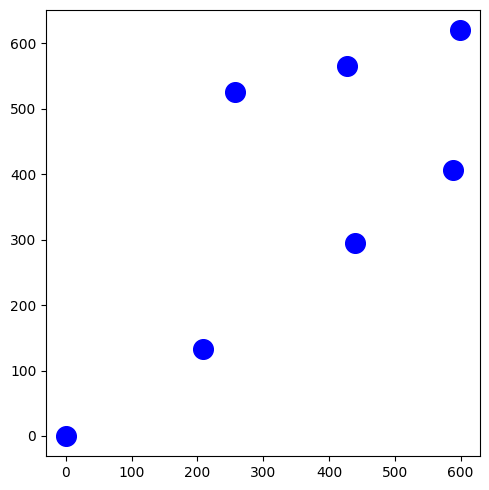

142599.27665150267


/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/home/codespace/.local/lib/python3.10/site-packages/IPython/core/formatters.py", line 223, in catch_format_error
    r = method(self, *args, **kwargs)
  File "/home/codespace/.local/lib/python3.10/site-packages/IPython/core/formatters.py", line 344, in __call__
    return method()
  File "/home/codespace/.python/current/lib/python3.10/site-packages/pandas/core/frame.py", line 1175, in _repr_html_
    else:
  File "/home/codespace/.python/current/lib/python3.10/site-packages/pandas/io/formats/format.py", line 1074, in to_html
  File "/home/codespace/.python/current/lib/python3.10/site-packages/pandas/io/formats/html.py", line 88, in to_string
    lines = self.render()
  File "/home/codespace/.python/current/lib/python3.10/site-packages/pandas/io/formats/html.py", line 644, in render
    super().render()
  File "/home/codespace/.python/current/lib/python3.10/site-packages/pandas/io/formats/html.py", line 94, in render
    self._write_table()
  F

     Layout_x    Layout_y
0    0.000000    0.000000
1  185.438552  612.237822
2  580.971252  599.554475
3  148.454696  252.810999
5  529.467654  376.120577
6  481.760735  127.860017
7  627.293008  239.594628

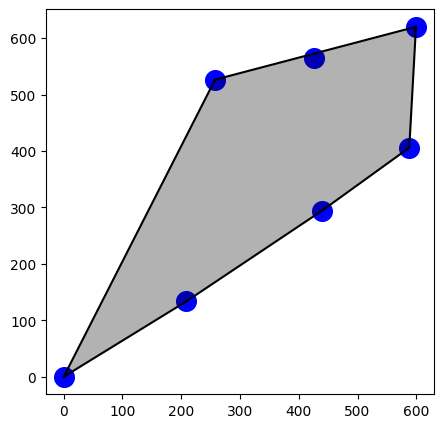

In [82]:
populations = initialize_populations()
best_layout = run_genetic_algorithm(populations)  # Get only the best layout
plot_best_layout(best_layout)  # Plot only the best layout
plot_best_layouts(best_layout)
print(calculate_enclosed_area(best_layout))
len(best_layout)

def get_gen1_populations():
    gen_1_pop = []
    for _ in range(40):
        best_layout = run_genetic_algorithm(populations)
        gen_1_pop.append(best_layout)
    return gen_1_pop

gen_1_pop = get_gen1_populations()
gen_1_pop[0]

  ### Floris Initailization

In [83]:
fi_nrel = FlorisInterface('./gch.yaml')
fi_vestas = FlorisInterface('./gch_vestas.yaml')

In [84]:
def powers(fi, gen_1_pop):
    power_list = []
    fi.reinitialize(
        layout_x=gen_1_pop["Layout_x"],
        layout_y=gen_1_pop['Layout_y'],
        wind_directions=wd_array,
        wind_speeds=ws_array,
    )

    aep = fi.get_farm_AEP(
        freq=freq,
        cut_in_wind_speed=4.0,  # Wakes are not evaluated below this wind speed
        cut_out_wind_speed=25.0,  # Wakes are not evaluated above this wind speed
    )
    power_list.append(round((aep / 1.0e9), 3))

    aep_no_wake = fi.get_farm_AEP(freq, no_wake=True)
    power_list.append(round((aep_no_wake / 1.0e9), 3))

    percentage_power_loss = (aep_no_wake - aep) / aep_no_wake * 100
    power_list.append(round(percentage_power_loss, 3))


    return power_list


# nrel_p1_powers[]
# populations = initialize_populations()
gen_1_pop = get_gen1_populations()

for _ in range(len(gen_1_pop)):
    nrel_p1_powers = powers(fi_nrel, gen_1_pop[_])
    print(nrel_p1_powers)

# for _ in range(len(populations)):
#     nrel_p1_powers = powers(fi_nrel, populations[_])
#     print(nrel_p1_powers)
# nrel_p1_powers = powers(fi_nrel, gen_1_pop[0])
# nrel_p1_powers

/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake

[59.597, 74.552, 20.06]
[61.635, 86.978, 29.137]
[56.632, 74.552, 24.038]
[65.191, 86.978, 25.049]


floris.tools.floris_interface.FlorisInterface WARNING Some rotor effective velocities are negative.


[61.522, 99.403, 38.109]
[63.41, 86.978, 27.096]
[70.259, 99.403, 29.319]


floris.tools.floris_interface.FlorisInterface WARNING Some rotor effective velocities are negative.


[55.813, 99.403, 43.852]
[65.907, 99.403, 33.697]
[61.087, 86.978, 29.767]
[61.607, 86.978, 29.17]
[63.507, 86.978, 26.985]
[65.322, 99.403, 34.286]
[70.379, 99.403, 29.198]
[61.863, 86.978, 28.875]


floris.tools.floris_interface.FlorisInterface WARNING Some rotor effective velocities are negative.


[54.501, 99.403, 45.172]
[66.915, 86.978, 23.067]
[58.863, 74.552, 21.045]
[61.228, 86.978, 29.605]
[57.937, 86.978, 33.389]
[45.69, 74.552, 38.715]
[58.179, 74.552, 21.962]
[66.972, 86.978, 23.001]
[64.75, 86.978, 25.555]
[63.186, 86.978, 27.354]
[59.693, 86.978, 31.37]
[56.891, 74.552, 23.691]
[63.55, 86.978, 26.936]
[65.306, 86.978, 24.916]
[64.72, 86.978, 25.59]
[69.276, 99.403, 30.308]
[70.292, 99.403, 29.286]
[56.688, 86.978, 34.825]
[60.377, 86.978, 30.583]
[66.342, 86.978, 23.726]
[70.858, 99.403, 28.716]
[65.669, 86.978, 24.499]
[57.507, 86.978, 33.883]
[70.665, 99.403, 28.911]
[65.429, 86.978, 24.775]


In [85]:


gen_2 = []
while len(gen_2) < 3:
    try:
        best_layout = run_genetic_algorithm(populations)
        nrel_p1_powers = powers(fi_nrel, best_layout)
        if nrel_p1_powers[2] < 20:
            gen_2.append(best_layout)
    except Exception as e:
        print(f"An error occurred: {e}")
        continue

len(gen_2)

/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)


/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake

An error occurred: 'DataFrame' object has no attribute 'append'


/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake

An error occurred: 'DataFrame' object has no attribute 'append'


...

An error occurred: 'DataFrame' object has no attribute 'append'


/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake

An error occurred: 'DataFrame' object has no attribute 'append'


/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_1744/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake

3

In [86]:
print(powers(fi_nrel, gen_2[0]))
print(powers(fi_nrel, gen_2[1]))
print(powers(fi_nrel, gen_2[2]))

[71.95, 86.978, 17.277]


floris.tools.floris_interface.FlorisInterface WARNING Some rotor effective velocities are negative.


[75.397, 86.978, 13.315]
[73.131, 86.978, 15.92]


In [87]:
print(gen_2[0])
print(gen_2[1])
print(gen_2[2])

     Layout_x    Layout_y
0    0.000000    0.000000
1  166.530577  612.237822
3  521.063282  252.810999
4  148.454696  354.139971
5  208.684566  133.589492
6  599.513387  133.589492
7  599.513387  133.589492
     Layout_x    Layout_y
0    0.000000    0.000000
1  239.435777  585.368022
3  343.259480  169.651341
4  156.667781  405.874075
5  156.667781  405.874075
6  627.293008  133.589492
7  627.293008  133.589492
     Layout_x    Layout_y
0    0.000000    0.000000
1  183.635486  612.237822
2  385.149704  571.650959
4  588.110039  133.589492
5  588.110039  133.589492
6  386.339708  133.589492
7  325.708521  356.710015


In [88]:
# populations.to_csv('populations_0.csv')

AttributeError: 'list' object has no attribute 'to_csv'

In [89]:
gen_2[0].to_csv('gen_2_15.csv')
gen_2[1].to_csv('gen_2_16.csv')
gen_2[2].to_csv('gen_2_17.csv')

ImportError: cannot import name 'SequenceNotStr' from 'pandas._typing' (/home/codespace/.python/current/lib/python3.10/site-packages/pandas/_typing.py)

In [ ]:
power_outputs = []
for layout in gen_1_pop:
    power_output = powers(fi_nrel, layout)
    power_outputs.append(power_output)

floris.tools.floris_interface.FlorisInterface WARNING Some rotor effective velocities are negative.
floris.tools.floris_interface.FlorisInterface WARNING Some rotor effective velocities are negative.


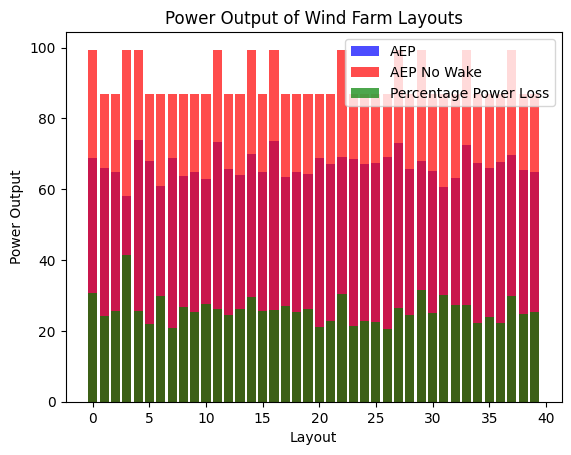

In [ ]:
import matplotlib.pyplot as plt

# Assuming power_outputs is a list of lists, where each sublist is [aep, aep_no_wake, percentage_power_loss]
aep_values = [output[0] for output in power_outputs]
aep_no_wake_values = [output[1] for output in power_outputs]
percentage_power_loss_values = [output[2] for output in power_outputs]

# Create a new figure
plt.figure()

# Create a bar plot for aep values
plt.bar(range(len(aep_values)), aep_values, color='b', alpha=0.7, label='AEP')

# Create a bar plot for aep_no_wake values
plt.bar(range(len(aep_no_wake_values)), aep_no_wake_values, color='r', alpha=0.7, label='AEP No Wake')

# Create a bar plot for percentage_power_loss values
plt.bar(range(len(percentage_power_loss_values)), percentage_power_loss_values, color='g', alpha=0.7, label='Percentage Power Loss')

# Add labels and title
plt.xlabel('Layout')
plt.ylabel('Power Output')
plt.title('Power Output of Wind Farm Layouts')
plt.legend()

# Show the plot
plt.show()